# Notebook 05 — Visualisations & démos

Charge les modèles entraînés (NB 01, 02, 03, 03b) et génère des **GIFs animés** des agents en action.

## GIFs produits

1. Agent aléatoire (baseline visuelle)
2. PPO-MLP sur CartPole-v1 (MDP) — devrait tenir 500 pas
3. PPO-MLP sur CartPole-MaskedVelocity — devrait tomber rapidement
4. **PPO-MLP + FrameStack sur CartPole-MaskedVelocity** — devrait bien tenir
5. PPO-LSTM sur CartPole-MaskedVelocity — n'a pas convergé (échec visible)
6. **Comparaison côte-à-côte des 4 agents** — slide phare de la présentation

## Installation

In [25]:
# !pip install -q pygame imageio imageio-ffmpeg

import importlib
missing = []
for mod in ["pygame", "imageio"]:
    if importlib.util.find_spec(mod) is None:
        missing.append(mod)
if missing:
    print(f"⚠️  Modules manquants : {missing}")
    print(f"   Lance : pip install {' '.join(missing)} imageio-ffmpeg")
else:
    print("✅ pygame + imageio OK")

✅ pygame + imageio OK


## Setup

In [26]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import imageio
from IPython.display import Image, display
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt

from src.envs.pomdp_wrappers import MaskVelocityWrapper, FrameStackWrapper
from src.agents.ppo_lstm import AgentLSTM

VIDEO_DIR = ROOT / "results" / "videos"
MODEL_DIR = ROOT / "results" / "models"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"\nModèles disponibles :")
for p in sorted(MODEL_DIR.glob("*.pt")):
    print(f"  - {p.name}")

Device: cpu

Modèles disponibles :
  - ppo_lstm_cartpole_masked__seed1.pt
  - ppo_mlp_cartpole_full__seed1.pt
  - ppo_mlp_cartpole_masked__seed1.pt
  - ppo_mlp_framestack_masked__seed1.pt


## Classe AgentMLP (pour recharger NB 01, NB 02, NB 03)

In [27]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class AgentMLP(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=64):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, 1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, n_actions), std=0.01),
        )
    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(x)

## Fonctions utilitaires pour enregistrer les épisodes

In [28]:
def record_episode_mlp(agent, env_builder, seed=42, max_steps=500, deterministic=True):
    """Enregistre un épisode joué par un agent MLP (avec ou sans FrameStack)."""
    env = env_builder()
    obs, _ = env.reset(seed=seed)
    frames = []
    total_r = 0
    for _ in range(max_steps):
        frames.append(env.render())
        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = agent.actor(obs_t)
            if deterministic:
                action = int(logits.argmax(dim=-1).item())
            else:
                action = int(Categorical(logits=logits).sample().item())
        obs, r, term, trunc, _ = env.step(action)
        total_r += r
        if term or trunc:
            frames.append(env.render())
            break
    env.close()
    return frames, total_r


def record_episode_lstm(agent, seed=42, max_steps=500, deterministic=True):
    """Enregistre un épisode joué par PPO-LSTM sur CartPole-MaskedVelocity."""
    env = MaskVelocityWrapper(gym.make("CartPole-v1", render_mode="rgb_array"))
    obs, _ = env.reset(seed=seed)
    lstm_state = agent.initial_state(batch_size=1, device=device)
    next_done = torch.zeros(1, device=device)
    frames = []
    total_r = 0
    for _ in range(max_steps):
        frames.append(env.render())
        with torch.no_grad():
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            hidden, lstm_state = agent.get_states(obs_t, lstm_state, next_done)
            logits = agent.actor(hidden)
            if deterministic:
                action = int(logits.argmax(dim=-1).item())
            else:
                action = int(Categorical(logits=logits).sample().item())
        obs, r, term, trunc, _ = env.step(action)
        total_r += r
        next_done = torch.tensor([float(term or trunc)], device=device)
        if term or trunc:
            frames.append(env.render())
            break
    env.close()
    return frames, total_r


def save_gif(frames, path, fps=30, max_frames=300):
    """Sauvegarde une liste de frames RGB en GIF."""
    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames)-1, max_frames).astype(int)
        frames = [frames[i] for i in idx]
    imageio.mimsave(path, frames, fps=fps, loop=0)
    print(f"  → {path.name} ({len(frames)} frames)")

## Démo 1 — Agent aléatoire

Agent aléatoire : retour = 16.0, longueur = 17
  → 01_random_agent.gif (17 frames)


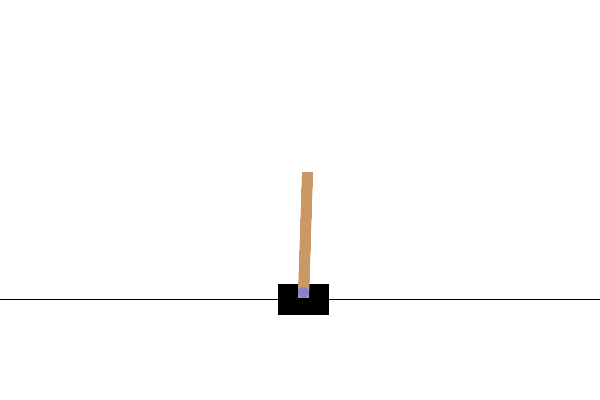

In [29]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset(seed=42)
frames = []
total_r = 0
for _ in range(500):
    frames.append(env.render())
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    total_r += r
    if term or trunc:
        frames.append(env.render())
        break
env.close()
print(f"Agent aléatoire : retour = {total_r}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "01_random_agent.gif")
display(Image(filename=str(VIDEO_DIR / "01_random_agent.gif")))

## Démo 2 — PPO-MLP sur CartPole-v1 (MDP)

PPO-MLP / MDP : retour = 500.0, longueur = 501
  → 02_ppo_mlp_mdp.gif (300 frames)


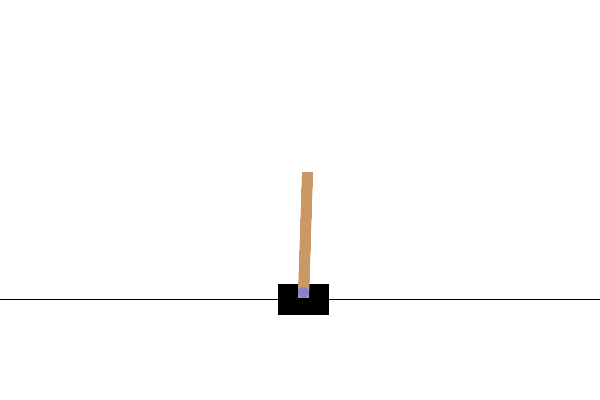

In [30]:
model_path = MODEL_DIR / "ppo_mlp_cartpole_full__seed1.pt"
assert model_path.exists(), f"Modèle manquant : {model_path}"

agent_mlp_mdp = AgentMLP(obs_dim=4, n_actions=2).to(device)
agent_mlp_mdp.load_state_dict(torch.load(model_path, map_location=device))
agent_mlp_mdp.eval()

env_builder = lambda: gym.make("CartPole-v1", render_mode="rgb_array")
frames, r = record_episode_mlp(agent_mlp_mdp, env_builder, seed=42)
print(f"PPO-MLP / MDP : retour = {r}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "02_ppo_mlp_mdp.gif")
display(Image(filename=str(VIDEO_DIR / "02_ppo_mlp_mdp.gif")))

## Démo 3 — PPO-MLP sur CartPole-MaskedVelocity (POMDP)

L'agent voit seulement `(x, theta)`. Devrait tomber vite faute d'information.

PPO-MLP / POMDP : retour = 47.0, longueur = 48
  → 03_ppo_mlp_pomdp.gif (48 frames)


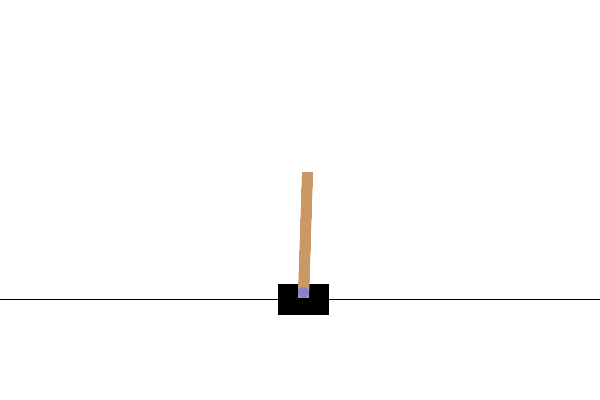

In [31]:
model_path = MODEL_DIR / "ppo_mlp_cartpole_masked__seed1.pt"
assert model_path.exists(), f"Modèle manquant : {model_path}"

agent_mlp_pomdp = AgentMLP(obs_dim=2, n_actions=2).to(device)
agent_mlp_pomdp.load_state_dict(torch.load(model_path, map_location=device))
agent_mlp_pomdp.eval()

env_builder = lambda: MaskVelocityWrapper(gym.make("CartPole-v1", render_mode="rgb_array"))
frames, r = record_episode_mlp(agent_mlp_pomdp, env_builder, seed=42)
print(f"PPO-MLP / POMDP : retour = {r}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "03_ppo_mlp_pomdp.gif")
display(Image(filename=str(VIDEO_DIR / "03_ppo_mlp_pomdp.gif")))

## Démo 4 — PPO-MLP + FrameStack sur CartPole-MaskedVelocity ⭐

L'agent reçoit les 4 dernières observations `(x, theta)`. Grâce à cet historique, il peut implicitement reconstruire les vitesses comme différences finies.

PPO-MLP + FrameStack / POMDP : retour = 500.0, longueur = 501
  → 04_ppo_framestack_pomdp.gif (300 frames)


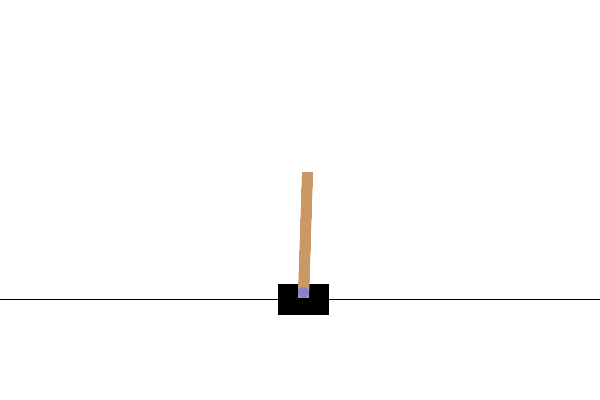

In [32]:
model_path = MODEL_DIR / "ppo_mlp_framestack_masked__seed1.pt"
assert model_path.exists(), f"Modèle manquant : {model_path}. As-tu lancé NB 03 ?"

# obs_dim = 8 car FrameStack(k=4) sur 2 dims
agent_framestack = AgentMLP(obs_dim=8, n_actions=2).to(device)
agent_framestack.load_state_dict(torch.load(model_path, map_location=device))
agent_framestack.eval()

env_builder = lambda: FrameStackWrapper(
    MaskVelocityWrapper(gym.make("CartPole-v1", render_mode="rgb_array")),
    k=4
)
frames, r = record_episode_mlp(agent_framestack, env_builder, seed=42)
print(f"PPO-MLP + FrameStack / POMDP : retour = {r}, longueur = {len(frames)}")
save_gif(frames, VIDEO_DIR / "04_ppo_framestack_pomdp.gif")
display(Image(filename=str(VIDEO_DIR / "04_ppo_framestack_pomdp.gif")))

## Démo 5 — PPO-LSTM sur CartPole-MaskedVelocity (résultat négatif documenté)

PPO-LSTM n'a pas convergé dans notre budget de timesteps. Cette démo montre visuellement l'échec, ce qui est utile pour le rapport (résultat négatif honnête).

In [33]:
model_path = MODEL_DIR / "ppo_lstm_cartpole_masked__seed1.pt"
if model_path.exists():
    # Reconstruire l'agent LSTM avec la même config que NB 03b
    # La config originale utilisait lstm_hidden_size=128 (ancien) ou 64 (nouveau)
    # On essaie d'abord 128, puis 64 si ça plante
    agent_lstm = None
    for lstm_h in [128, 64]:
        try:
            tmp = AgentLSTM(obs_dim=2, n_actions=2, hidden_size=64, lstm_hidden_size=lstm_h).to(device)
            tmp.load_state_dict(torch.load(model_path, map_location=device))
            tmp.eval()
            agent_lstm = tmp
            print(f"Chargé avec lstm_hidden_size={lstm_h}")
            break
        except RuntimeError:
            continue
    
    if agent_lstm is not None:
        frames, r = record_episode_lstm(agent_lstm, seed=42)
        print(f"PPO-LSTM / POMDP : retour = {r}, longueur = {len(frames)}")
        save_gif(frames, VIDEO_DIR / "05_ppo_lstm_pomdp.gif")
        display(Image(filename=str(VIDEO_DIR / "05_ppo_lstm_pomdp.gif")))
    else:
        print("⚠️  Impossible de charger le modèle LSTM (config incompatible). Skip.")
else:
    print("⚠️  Modèle LSTM absent — NB 03b non exécuté. Skip.")

⚠️  Impossible de charger le modèle LSTM (config incompatible). Skip.


## Démo 6 — Comparaison côte-à-côte (slide phare) ⭐⭐

Les 4 agents jouent en parallèle avec la même seed. C'est l'image qui résume tout le projet.

Génération des 4 trajectoires avec seed unifiée...
  1. PPO-MLP / MDP             : retour=500.0
  2. PPO-MLP / POMDP           : retour=34.0
  3. PPO-MLP+FrameStack/POMDP  : retour=500.0
  → 06_comparison_side_by_side.gif (300 frames)

De gauche à droite : MLP/MDP | MLP/POMDP | MLP+FS/POMDP
Retours              : 500.0 | 34.0 | 500.0


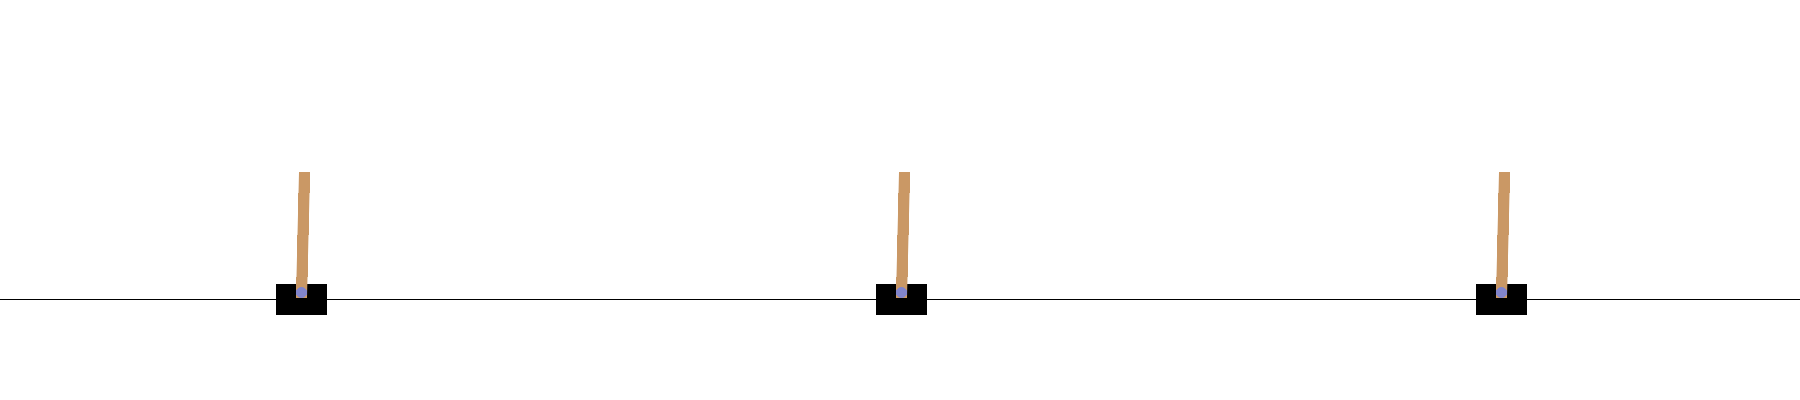

In [34]:
SEED_VIZ = 7

# Re-jouer tous les agents avec la même seed
print("Génération des 4 trajectoires avec seed unifiée...")

env_mdp = lambda: gym.make("CartPole-v1", render_mode="rgb_array")
frames_mdp, r1 = record_episode_mlp(agent_mlp_mdp, env_mdp, seed=SEED_VIZ)
print(f"  1. PPO-MLP / MDP             : retour={r1}")

env_pomdp_mlp = lambda: MaskVelocityWrapper(gym.make("CartPole-v1", render_mode="rgb_array"))
frames_pomdp_mlp, r2 = record_episode_mlp(agent_mlp_pomdp, env_pomdp_mlp, seed=SEED_VIZ)
print(f"  2. PPO-MLP / POMDP           : retour={r2}")

env_fs = lambda: FrameStackWrapper(MaskVelocityWrapper(gym.make("CartPole-v1", render_mode="rgb_array")), k=4)
frames_fs, r3 = record_episode_mlp(agent_framestack, env_fs, seed=SEED_VIZ)
print(f"  3. PPO-MLP+FrameStack/POMDP  : retour={r3}")

# LSTM est optionnel selon disponibilité
has_lstm = (MODEL_DIR / "ppo_lstm_cartpole_masked__seed1.pt").exists()
if has_lstm and 'agent_lstm' in dir() and agent_lstm is not None:
    frames_lstm, r4 = record_episode_lstm(agent_lstm, seed=SEED_VIZ)
    print(f"  4. PPO-LSTM / POMDP          : retour={r4}")
    panels = [frames_mdp, frames_pomdp_mlp, frames_fs, frames_lstm]
    labels = ["MLP/MDP", "MLP/POMDP", "MLP+FS/POMDP", "LSTM/POMDP"]
    returns_list = [r1, r2, r3, r4]
else:
    panels = [frames_mdp, frames_pomdp_mlp, frames_fs]
    labels = ["MLP/MDP", "MLP/POMDP", "MLP+FS/POMDP"]
    returns_list = [r1, r2, r3]

# Aligner les longueurs
max_len = max(len(p) for p in panels)
def pad(frames, target_len):
    if len(frames) < target_len:
        return frames + [frames[-1]] * (target_len - len(frames))
    return frames[:target_len]
panels_padded = [pad(p, max_len) for p in panels]

# Concaténer horizontalement frame par frame
combined_frames = []
for t in range(max_len):
    row = np.concatenate([panels_padded[i][t] for i in range(len(panels))], axis=1)
    combined_frames.append(row)

save_gif(combined_frames, VIDEO_DIR / "06_comparison_side_by_side.gif")
print(f"\nDe gauche à droite : {' | '.join(labels)}")
print(f"Retours              : {' | '.join(str(r) for r in returns_list)}")
display(Image(filename=str(VIDEO_DIR / "06_comparison_side_by_side.gif")))

## Bonus pédagogique — Que voit l'agent ?

Figure pour la section Méthodologie du rapport.

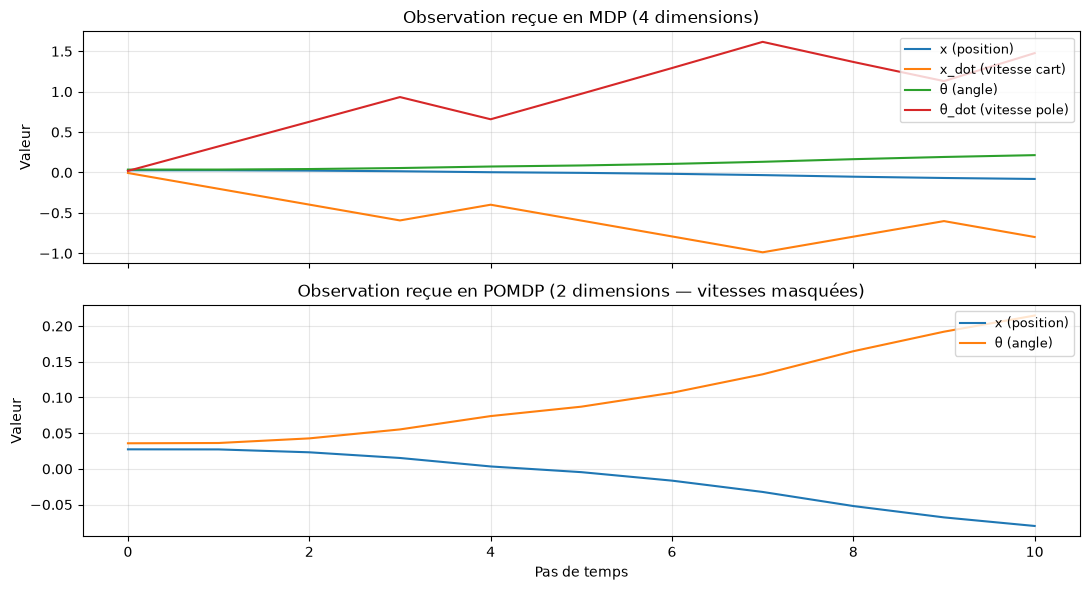

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\report\figures\obs_mdp_vs_pomdp.png

→ À insérer dans la section 3.1 'Environnement' du rapport.


In [35]:
env_mdp = gym.make("CartPole-v1")
env_pomdp = MaskVelocityWrapper(gym.make("CartPole-v1"))

obs_mdp, _ = env_mdp.reset(seed=42)
obs_pomdp, _ = env_pomdp.reset(seed=42)
trajectory_mdp = [obs_mdp.copy()]
trajectory_pomdp = [obs_pomdp.copy()]

for _ in range(50):
    a = env_mdp.action_space.sample()
    obs_mdp, _, term1, trunc1, _ = env_mdp.step(a)
    obs_pomdp, _, term2, trunc2, _ = env_pomdp.step(a)
    trajectory_mdp.append(obs_mdp.copy())
    trajectory_pomdp.append(obs_pomdp.copy())
    if term1 or trunc1: break

trajectory_mdp = np.array(trajectory_mdp)
trajectory_pomdp = np.array(trajectory_pomdp)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
labels_mdp = ["x (position)", "x_dot (vitesse cart)", "θ (angle)", "θ_dot (vitesse pole)"]
for i in range(4):
    axes[0].plot(trajectory_mdp[:, i], label=labels_mdp[i])
axes[0].set_title("Observation reçue en MDP (4 dimensions)")
axes[0].set_ylabel("Valeur")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].grid(alpha=0.3)

labels_pomdp = ["x (position)", "θ (angle)"]
for i in range(2):
    axes[1].plot(trajectory_pomdp[:, i], label=labels_pomdp[i])
axes[1].set_title("Observation reçue en POMDP (2 dimensions — vitesses masquées)")
axes[1].set_xlabel("Pas de temps")
axes[1].set_ylabel("Valeur")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig_path = ROOT / "report" / "figures" / "obs_mdp_vs_pomdp.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Figure → {fig_path}")
print("\n→ À insérer dans la section 3.1 'Environnement' du rapport.")

## ✅ Récapitulatif des artefacts

| Fichier | Usage |
|---|---|
| `results/videos/01_random_agent.gif` | Baseline visuelle |
| `results/videos/02_ppo_mlp_mdp.gif` | Démo MDP résolu |
| `results/videos/03_ppo_mlp_pomdp.gif` | Démo échec sans mémoire |
| `results/videos/04_ppo_framestack_pomdp.gif` | **Démo réussite FrameStack** ⭐ |
| `results/videos/05_ppo_lstm_pomdp.gif` | Démo échec LSTM (résultat négatif) |
| `results/videos/06_comparison_side_by_side.gif` | **Slide phare présentation** ⭐⭐ |
| `report/figures/obs_mdp_vs_pomdp.png` | Figure pédagogique pour le rapport |